In [1]:
import numpy as np
import physipy as phys
import matplotlib.pyplot as plt
import math
from scipy.integrate import simpson

alpha = 0.10
alpha = 0.20
alpha = 0.30
alpha = 0.40
alpha = 0.50
alpha = 0.60
alpha = 0.70
alpha = 0.80
alpha = 0.90
alpha = 1.00


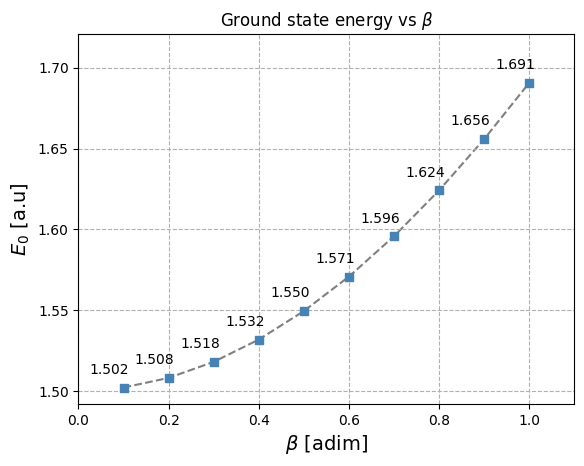

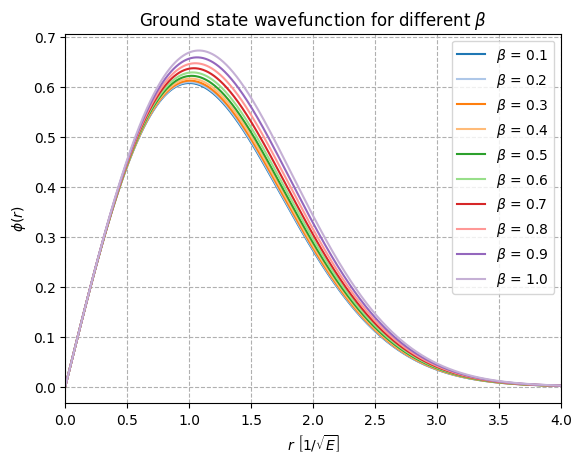

In [ ]:
# Numerov grid
grid = phys.Grid(1e-4, 10, 1e-3)
coord = grid.coord

g = 1 # coupling constant
E = np.arange(0, 5, 0.1)
l = np.array([0, ])
alphas  = np.arange(.1, 1.1, .1)

gr_energies = []
gr_wavefunction = []

cmap = plt.get_cmap('tab20')
i = 0

for alpha in alphas:
    print(f'alpha = {alpha:.2f}')
    phi_guess = alpha * np.exp(-np.pow(coord, 2) / 2) * coord / math.pow(math.pi, 1/4)
    kwargs = {'g' : g, 'guess' : phi_guess, 'grid_gp' : grid}
    eigenstates = phys.energy_levels(E, l, phys.potentials.gross_pitaevskij, 0 , grid = grid, solver = phys.SolverOpts(), **kwargs)
    gr_energies.append(eigenstates[0].E)
    gr_wavefunction.append(eigenstates[0].psi)

# draw the trend of ground state energies vs alpha
for xi, yi in zip(alphas, gr_energies):
    plt.annotate(f'{yi:.3f}', (xi, yi), 
                 textcoords='offset points', 
                 xytext=(-10, 10),  # offset in points: (horizontal, vertical)
                 ha='center')
plt.plot(alphas, gr_energies, color='grey', linestyle='dashed', zorder=1)
plt.scatter(alphas, gr_energies, marker='s', color='steelblue', zorder=2)
plt.title("Ground state energy vs " + r'$\beta$')
plt.xlim(0, 1.1)
plt.ylim(np.min(gr_energies) - 0.01, np.max(gr_energies) + 0.03)
plt.xlabel(r'$\beta$ [adim]', fontsize = 14)
plt.ylabel(r'$E_0$ [a.u]', fontsize = 14)
plt.grid(ls = '--')
plt.savefig('imgs/assignment 3/gs_energy_alpha.pdf', bbox_inches='tight')
plt.show()

# draw the different ground state wavefunctions for all alphas
j = 0
for psi, alpha in zip(gr_wavefunction, alphas):
    plt.plot(coord, psi, c = cmap(j), label = r'$\beta$' + f' = {alpha:.1f}')
    j += 1
plt.title(r'Ground state wavefunction for different $\beta$')
plt.xlabel(r'$r$ $\left [ 1/\sqrt{E} \right ]$')
plt.ylabel(r'$\phi(r)$')
plt.xlim(0, 4)
plt.grid(ls = '--')
plt.legend()
plt.savefig('imgs/assignment 3/gs_wavefunction_alpha.pdf', bbox_inches='tight')
plt.show()


Converged at iteration 25: g = -1.00e-01 alpha = 4.00e-01 mu = 1.4157  E = 1.4587  wf_diff = 7.43e-07  E_residual = 7.74e-05  (tol = 1.0e-06)
Converged at iteration 28: g = -2.00e-01 alpha = 4.00e-01 mu = 1.3193  E = 1.4137  wf_diff = 8.71e-07  E_residual = 7.87e-05  (tol = 1.0e-06)
Converged at iteration 34: g = -3.00e-01 alpha = 4.00e-01 mu = 1.2053  E = 1.3638  wf_diff = 9.20e-07  E_residual = 8.20e-05  (tol = 1.0e-06)
Converged at iteration 44: g = -4.00e-01 alpha = 4.00e-01 mu = 1.0614  E = 1.3070  wf_diff = 9.20e-07  E_residual = 8.57e-05  (tol = 1.0e-06)
Converged at iteration 66: g = -5.00e-01 alpha = 4.00e-01 mu = 0.8502  E = 1.2385  wf_diff = 6.88e-07  E_residual = 9.29e-05  (tol = 1.0e-06)


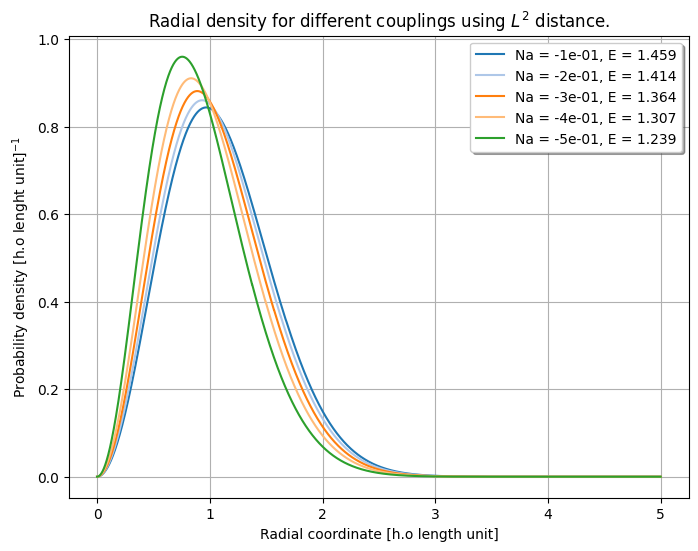

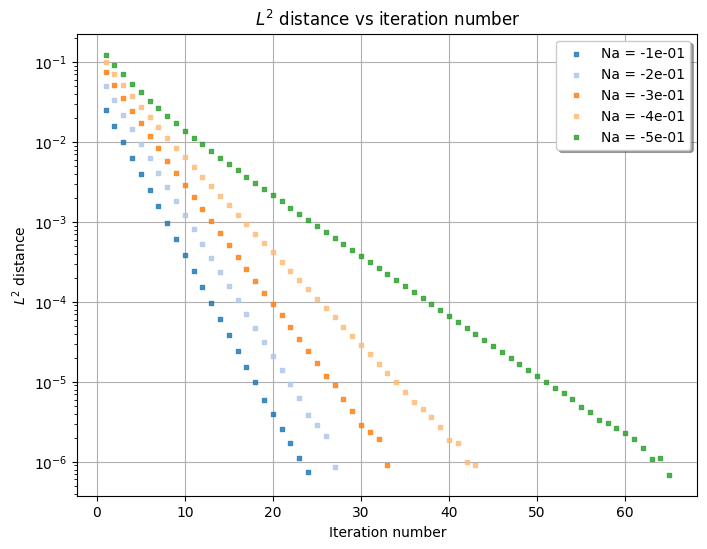

In [6]:
grid = phys.Grid(r_min=1e-4, r_max=5, h=1e-3)
coord = grid.coord
E = np.arange(0, 10, 0.01)

positive = False

if positive:
    gs = [.01, .1, 1, 10, 100]
    alphas = [0.6, 0.4, 0.3, 0.1, 0.05]
    filename = 'positive'
else:
    gs = [-.1, -.2, -.3, -.4, -.5]
    alphas = [.4, .4, .4, .4, .4]
    filename = 'negative'

cmap = plt.get_cmap('tab20')
i = 0

# plots
fig1, ax1 = plt.subplots(figsize = (8, 6))
fig2, ax2 = plt.subplots(figsize = (8, 6))

for g, alpha in zip(gs, alphas):
    try:
        E_func, mu, psi, error = phys.self_consistent_gp(
            E,
            g         = g,
            max_iterations = 10000,
            tol       = 1e-6,
            alpha     = alpha,
            grid      = grid,
            verbose   = False,
            keep_error = True
        )
        ax1.plot(coord, psi * psi, color = cmap(i), label = f'Na = {g:.0e}, E = {E_func:.3f}')
        ax2.scatter(np.arange(1, len(error) + 1, 1), error, s = 12, alpha = 0.8, marker='s', color=cmap(i), label = f'Na = {g:.0e}', zorder = 10 - i)
        i += 1
    except phys.numerics_data.ConvergenceError as e:
        print(f'Not converged after {e.max_iter} for g = {g} tol = 1e-3, last error = {e.delta_E}')


# wavefunction plot
ax1.legend(fancybox = True, shadow = True)
ax1.set_title(r'Radial density for different couplings using $L^2$ distance.')
ax1.set_xlabel('Radial coordinate [h.o length unit]')
ax1.set_ylabel(r'Probability density [h.o lenght unit]$^{-1}$')
ax1.grid()

# error plot
ax2.legend(fancybox = True, shadow = True)
ax2.set_title(r'$L^2$ distance vs iteration number')
ax2.set_xlabel('Iteration number')
ax2.set_ylabel(r'$L^2$ distance')
ax2.set_yscale('log')
ax2.grid()

# save images
fig1.savefig(
    f"imgs/assignment 3/gs_wavefunction_l_2_distance_{filename}.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
fig2.savefig(
    f"imgs/assignment 3/gs_iteration_error_l_2_distance_{filename}.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

Converged at iteration 22: g = -5.00e-02 alpha = 4.00e-01 mu = 1.4592  E = 1.4797  wf_diff = 7.89e-07  E_residual = 1.95e-04  (tol = 1.0e-06)
Converged at iteration 25: g = -1.00e-01 alpha = 4.00e-01 mu = 1.4157  E = 1.4586  wf_diff = 7.43e-07  E_residual = 2.02e-04  (tol = 1.0e-06)
Converged at iteration 27: g = -1.50e-01 alpha = 4.00e-01 mu = 1.3693  E = 1.4366  wf_diff = 7.33e-07  E_residual = 2.09e-04  (tol = 1.0e-06)
Converged at iteration 28: g = -2.00e-01 alpha = 4.00e-01 mu = 1.3193  E = 1.4135  wf_diff = 8.71e-07  E_residual = 2.19e-04  (tol = 1.0e-06)
Converged at iteration 32: g = -2.50e-01 alpha = 4.00e-01 mu = 1.2650  E = 1.3893  wf_diff = 9.72e-07  E_residual = 2.30e-04  (tol = 1.0e-06)
Converged at iteration 34: g = -3.00e-01 alpha = 4.00e-01 mu = 1.2053  E = 1.3636  wf_diff = 9.20e-07  E_residual = 2.43e-04  (tol = 1.0e-06)
Converged at iteration 40: g = -3.50e-01 alpha = 4.00e-01 mu = 1.1383  E = 1.3363  wf_diff = 3.48e-07  E_residual = 2.59e-04  (tol = 1.0e-06)
Conver

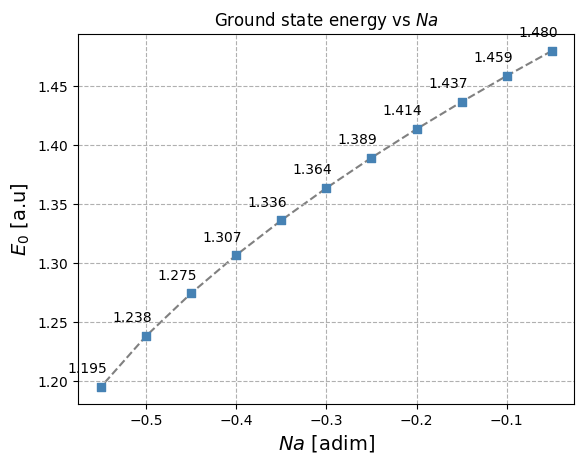

In [51]:
grid = phys.Grid(r_min=1e-4, r_max=5, h=1e-3)
coord = grid.coord
E = np.arange(0, 10, 0.01)

gs = np.arange(-.6, 0, .05)[::-1]
alpha = .4

gr_energies = []

for g in gs:
    try:
        E_func, mu, psi, error = phys.self_consistent_gp(
            E,
            g         = g,
            max_iterations = 1000,
            tol       = 1e-6,
            alpha     = alpha,
            grid      = grid,
            verbose   = False,
            keep_error = True
        )
        gr_energies.append(E_func)
    except phys.numerics_data.ConvergenceError as e:
        print(f'Not converges for g = {g}')
        break

gs = gs[:len(gr_energies)]
for xi, yi in zip(gs, gr_energies):
    plt.annotate(f'{yi:.3f}', (xi, yi), 
                 textcoords='offset points', 
                 xytext=(-10, 10),  # offset in points: (horizontal, vertical)
                 ha='center')
plt.plot(gs, gr_energies, color='grey', linestyle='dashed', zorder=1)
plt.scatter(gs, gr_energies, marker='s', color='steelblue', zorder=2)
plt.title("Ground state energy vs " + r'$Na$')
plt.xlabel(r'$Na$ [adim]', fontsize = 14)
plt.ylabel(r'$E_0$ [a.u]', fontsize = 14)
plt.grid(ls = '--')
plt.savefig('imgs/assignment 3/gs_energy_negative_coupling.pdf', bbox_inches='tight')
plt.show()

Iteration 1: g = 1.00e-02 alpha = 6.00e-01 mu = 1.5080  E = 1.5040  L2_dist = 2.56e-03  E_residual = 3.56e-05  (tol = 1.0e-03)
Converged at iteration 2: g = 1.00e-02 alpha = 6.00e-01 mu = 1.5080  E = 1.5040  wf_diff = 3.56e-05  E_residual = 3.56e-05  (tol = 1.0e-03)
Iteration 1: g = 1.00e-01 alpha = 4.00e-01 mu = 1.5784  E = 1.5386  L2_dist = 2.56e-02  E_residual = 2.66e-03  (tol = 1.0e-03)
Iteration 2: g = 1.00e-01 alpha = 4.00e-01 mu = 1.5773  E = 1.5386  L2_dist = 1.47e-02  E_residual = 1.52e-03  (tol = 1.0e-03)
Iteration 3: g = 1.00e-01 alpha = 4.00e-01 mu = 1.5767  E = 1.5386  L2_dist = 8.43e-03  E_residual = 8.79e-04  (tol = 1.0e-03)
Converged at iteration 4: g = 1.00e-01 alpha = 4.00e-01 mu = 1.5767  E = 1.5386  wf_diff = 8.79e-04  E_residual = 8.79e-04  (tol = 1.0e-03)
Iteration 1: g = 1.00e+00 alpha = 3.00e-01 mu = 2.1595  E = 1.8358  L2_dist = 2.52e-01  E_residual = 1.18e-01  (tol = 1.0e-03)
Iteration 2: g = 1.00e+00 alpha = 3.00e-01 mu = 2.1218  E = 1.8188  L2_dist = 1.39e-0

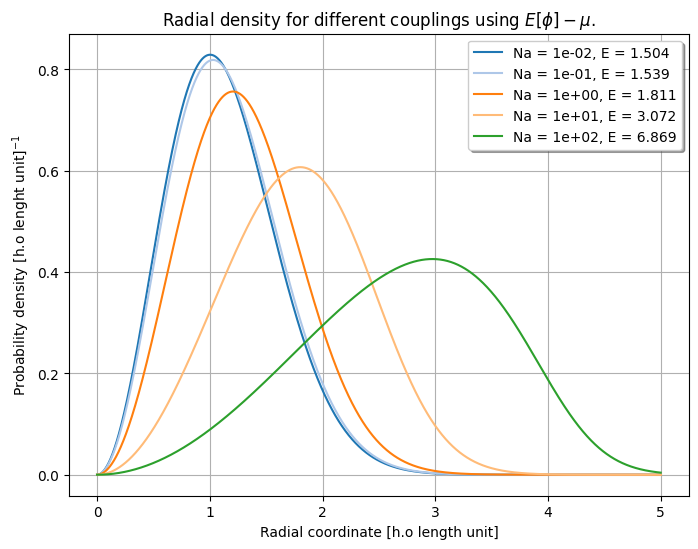

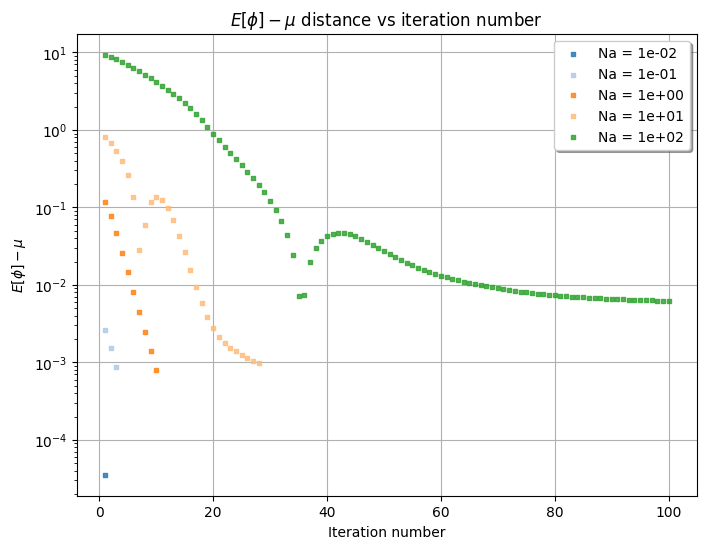

In [7]:
grid = phys.Grid(r_min = 1e-30, r_max = 5, h = 1e-4)
coord = grid.coord
E = np.arange(0, 10, 1e-2)

positive = True

if positive:
    gs = [.01, .1, 1, 10, 100]
    alphas = [0.6, 0.4, 0.3, 0.1, 0.05]
    filename = 'positive'
else:
    gs = [-.1, -.2, -.3, -.4, -.5]
    alphas = [.4, .4, .4, .4, .4]
    filename = 'negative'

cmap = plt.get_cmap('tab20')
i = 0

# plots
fig1, ax1 = plt.subplots(figsize = (8, 6))
fig2, ax2 = plt.subplots(figsize = (8, 6))

for g, alpha in zip(gs, alphas):
    E_func, mu, psi, error = phys.self_consistent_gp(
        E,
        g         = g,
        guess = None,
        max_iterations = 100,
        tol       = 1e-3,
        alpha = alpha,
        grid      = grid,
        verbose   = True,
        keep_error = True,
        convergence_crit = 'functional',
        throw = False
    )
    ax1.plot(coord, psi * psi, color = cmap(i), label = f'Na = {g:.0e}, E = {E_func:.3f}')
    ax2.scatter(np.arange(1, len(error) + 1, 1), error, s = 12, alpha = 0.8, marker='s', color=cmap(i), label = f'Na = {g:.0e}', zorder = 10 - i)
    i += 1


# wavefunction plot
ax1.legend(fancybox = True, shadow = True)
ax1.set_title(r'Radial density for different couplings using $E[\phi] - \mu$.')
ax1.set_xlabel('Radial coordinate [h.o length unit]')
ax1.set_ylabel(r'Probability density [h.o lenght unit]$^{-1}$')
ax1.grid()

# error plot
ax2.legend(fancybox = True, shadow = True)
ax2.set_title(r'$E[\phi] - \mu$ distance vs iteration number')
ax2.set_xlabel('Iteration number')
ax2.set_ylabel(r'$E[\phi] - \mu$')
ax2.set_yscale('log')
ax2.grid()

# save images
fig1.savefig(
    f"imgs/assignment 3/gs_wavefunction_functional_{filename}.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
fig2.savefig(
    f"imgs/assignment 3/gs_iteration_error_functional_{filename}.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()